In [29]:
# This is the Data cleaning file

#importing all libraries

import pandas as pd      #  for data manipulation 
import numpy as np       # For numerical operations, especially with missing values 



# Load the dataset
file_path = "cleaned_full_personal_finance.csv"
df = pd.read_csv(file_path)

#Understanding the DATA
# --- Phase 1: Initial Setup  ---

# Step 1.1: Initial Inspection 
print("\n--- Initial Inspection of Loaded Data ---")
print("DataFrame Info:")
df.info() # Gets a summary of the DataFrame, including column names, non-null counts, and data types

print("\nFirst 5 rows of the DataFrame:")
print(df.head()) # Display the first 5 rows to see the data structure and values



--- Initial Inspection of Loaded Data ---
DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Date                       101000 non-null  object 
 1   Description                101000 non-null  object 
 2   Category                   101000 non-null  object 
 3   Amount                     101000 non-null  float64
 4   Type                       101000 non-null  object 
 5   Notes                      101000 non-null  object 
 6   Merchant                   95958 non-null   object 
 7   Payment Method             95948 non-null   object 
 8   Balance After Transaction  101000 non-null  float64
 9   Currency                   101000 non-null  object 
 10  Transaction ID             101000 non-null  object 
 11  Account Type               101000 non-null  object 
 12  Transaction Type           

In [30]:

# --- Data Statistics: Mean, Median, Mode ---
print("--- Statistics for 'Amount' (Numerical) ---")
print(f"Mean Amount: {df['Amount'].mean():.2f}")
print(f"Median Amount: {df['Amount'].median():.2f}")
print("Mode Amount(s):")
print(df['Amount'].mode()) 

print("\n" + "="*50 + "\n")

print("--- Statistics for 'Merchant' (Categorical) ---")
print("Most Frequent Merchant(s) (Mode):")
print(df['Merchant'].mode())
print("\nTop 10 Merchants by Frequency:")

df['Merchant'].value_counts().head(10)





--- Statistics for 'Amount' (Numerical) ---
Mean Amount: 386.11
Median Amount: 345.06
Mode Amount(s):
0    10.722772
Name: Amount, dtype: float64


--- Statistics for 'Merchant' (Categorical) ---
Most Frequent Merchant(s) (Mode):
0    Netflix
Name: Merchant, dtype: object

Top 10 Merchants by Frequency:


Merchant
Netflix      12023
Amazon       12021
Spotify      12018
Target       12015
Walmart      12007
Lyft         11989
McDonalds    11984
Uber         11901
Name: count, dtype: int64

In [31]:
print("--- Statistics for 'Payment Method' (Categorical) ---")
print("Most Frequent Payment Method(s) (Mode):")
print(df['Payment Method'].mode())
print("\nTop 5 Payment Methods by Frequency:")

df['Payment Method'].value_counts().head(5)

--- Statistics for 'Payment Method' (Categorical) ---
Most Frequent Payment Method(s) (Mode):
0    Credit Card
Name: Payment Method, dtype: object

Top 5 Payment Methods by Frequency:


Payment Method
Credit Card       19304
Debit Card        19239
Bank Transfer     19161
Cash              19146
Mobile Payment    19098
Name: count, dtype: int64

In [32]:
# --- Statistics for 'Location' (Categorical) ---

print("--- Statistics for 'Location' ---")

# Most Frequent Location(s) (Mode)
print("Most Frequent Location(s) (Mode):")
print(df['Location'].mode()) # Returns the location(s) that appear most often

print("\nTop 10 Locations by Frequency:")
# Value counts show the frequency of each unique location
# .head(10) limits it to the top 10 most common locations
df['Location'].value_counts().head(10)

--- Statistics for 'Location' ---
Most Frequent Location(s) (Mode):
0    Lake Mark
Name: Location, dtype: object

Top 10 Locations by Frequency:


Location
Lake Mark             2018
Port Audreyside       1988
Hullport              1985
Port Heidi            1979
West Chloefort        1974
Michaelburgh          1963
Lake Brittany         1960
Barbaraport           1959
New Tannerville       1958
Port Gabriellafort    1955
Name: count, dtype: int64

In [33]:


# ---  Data Cleaning: Convert 'Time' and Extract 'Hour_Of_Day' ---

# First, ensuring 'Time' column is string type and handle any potential non-string values
df['Time'] = df['Time'].astype(str)

# Extract hour directly from string for robustness 
#  use regex to grab the first two digits only such as 06: or 12:
df['Hour_Of_Day'] = df['Time'].str.extract(r'^(\d{2}):', expand=False).astype(float)



print("\n--- After  'Hour_Of_Day' extraction ---")
df.info() 

print("\nFirst 5 rows with 'Time' and 'Hour_Of_Day':")
print(df[['Time', 'Hour_Of_Day', 'Location']].head())

# Check for any NaNs in Hour_Of_Day
print("\nNulls in Hour_Of_Day after extraction:")
print(df['Hour_Of_Day'].isnull().sum())


--- After  'Hour_Of_Day' extraction ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Date                       101000 non-null  object 
 1   Description                101000 non-null  object 
 2   Category                   101000 non-null  object 
 3   Amount                     101000 non-null  float64
 4   Type                       101000 non-null  object 
 5   Notes                      101000 non-null  object 
 6   Merchant                   95958 non-null   object 
 7   Payment Method             95948 non-null   object 
 8   Balance After Transaction  101000 non-null  float64
 9   Currency                   101000 non-null  object 
 10  Transaction ID             101000 non-null  object 
 11  Account Type               101000 non-null  object 
 12  Transaction Type           101000 non-null  o


--- Top 10 Most Frequent Locations ---
Location
Lake Mark             2018
Port Audreyside       1988
Hullport              1985
Port Heidi            1979
West Chloefort        1974
Michaelburgh          1963
Lake Brittany         1960
Barbaraport           1959
New Tannerville       1958
Port Gabriellafort    1955
Name: count, dtype: int64



--- Cross-tabulation: Transactions by Hour of Day for Top 10 Locations ---
Location     Barbaraport  Hullport  Lake Brittany  Lake Mark  Michaelburgh  \
Hour_Of_Day                                                                  
0                     75       103             83        118            72   
1                     96        96             83         72            81   
2                     70        82             95         73            76   
3                    107        84             84         93            81   
4                     72        79             85         73            90   
5                     84       

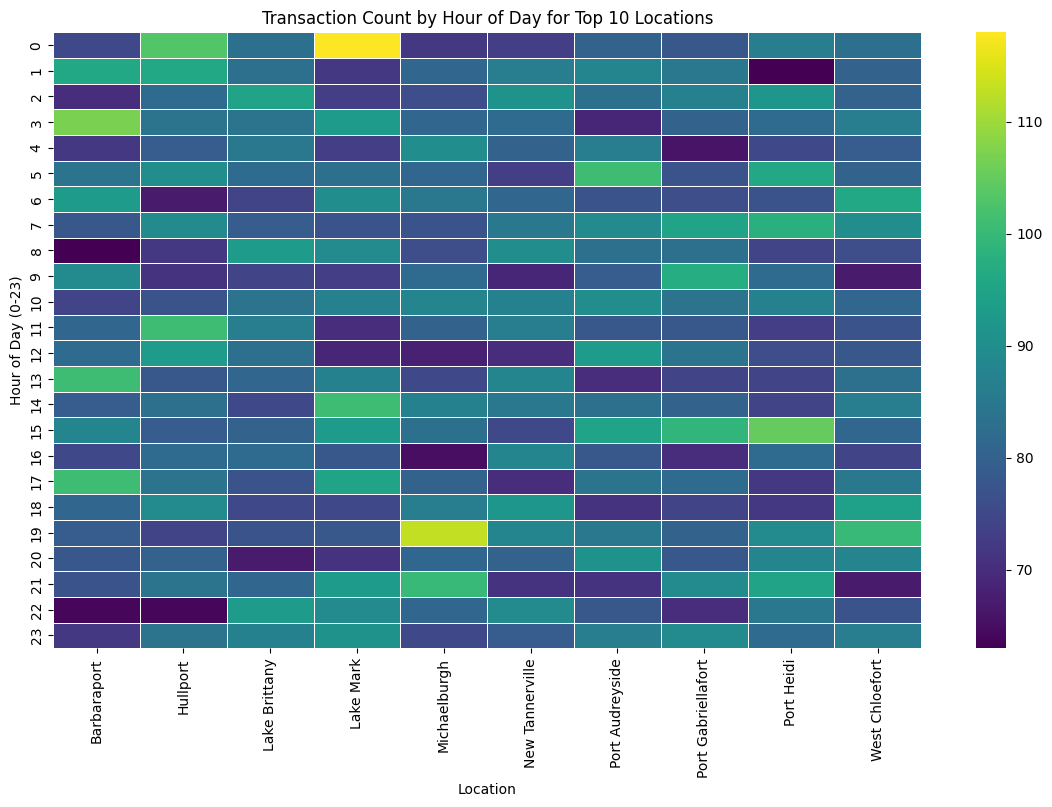


--- Performing Chi-square Test for Location vs. Hour of Day ---
Chi-square Statistic: 220.11
P-value: 0.253
Degrees of Freedom (dof): 207

--- Interpretation ---
Since the p-value (0.253) is greater than the significance level (0.05),
we fail to reject the null hypothesis.
Conclusion: There is no statistically significant association between 'Location' and 'Hour of Day'.
This means the pattern of transaction times is independent of the location (or we don't have enough evidence to say otherwise).

--- Activity distribution for 'Lake Mark' ---


C:\Users\souma\AppData\Local\Temp\ipykernel_7252\467694246.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=location_time_df_filtered[location_time_df_filtered['Location'] == example_location],


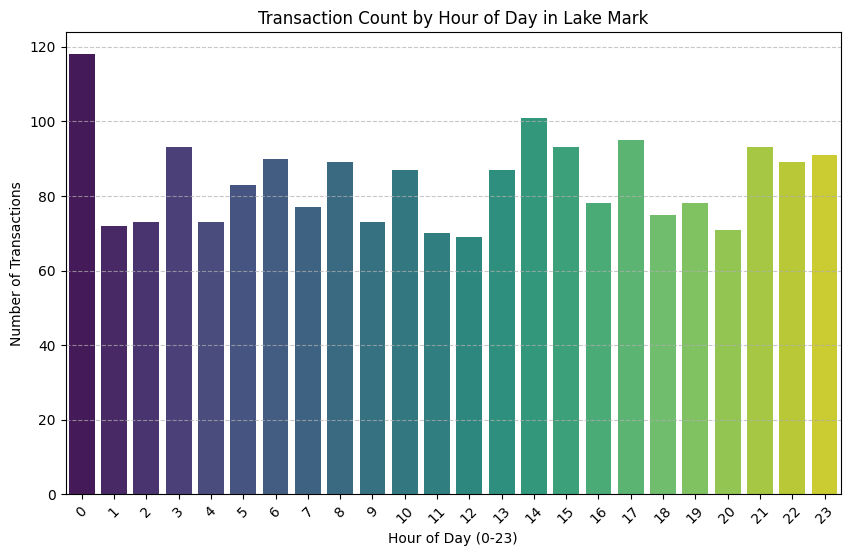

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Explpring the correlation between time and location

print("\n--- Top 10 Most Frequent Locations ---")
print(df['Location'].value_counts().head(10))

print("\n" + "="*50 + "\n")

# Analyzing Location activity by Hour of Day
# First, we need to clean the data for NaNs in 'Location' and 'Hour_Of_Day' if they exist, for this analysis
location_time_df = df.dropna(subset=['Location', 'Hour_Of_Day']).copy()
location_time_df['Hour_Of_Day'] = location_time_df['Hour_Of_Day'].astype(int) # hour needs to be an int

# Get top ten locations for clearer visualization 
top_locations = location_time_df['Location'].value_counts().head(10).index.tolist()
location_time_df_filtered = location_time_df[location_time_df['Location'].isin(top_locations)]

print(f"\n--- Cross-tabulation: Transactions by Hour of Day for Top {len(top_locations)} Locations ---")
# Create a pivot table to count transactions per hour per location
location_hour_counts = location_time_df_filtered.pivot_table(
    index='Hour_Of_Day',
    columns='Location',
    aggfunc='size', # number of occurrences
    fill_value=0
)
print(location_hour_counts)

print("\n" + "="*50 + "\n")

# --- Visualization: Heatmap of Location vs. Hour of Day ---
print("\n--- Visualizing Location Activity by Hour of Day ---")

plt.figure(figsize=(14, 8))
sns.heatmap(location_hour_counts, cmap='viridis', annot=False, fmt='d', linewidths=.5)
plt.title(f'Transaction Count by Hour of Day for Top {len(top_locations)} Locations')
plt.xlabel('Location')
plt.ylabel('Hour of Day (0-23)')
plt.show()

import scipy.stats as stats

# --- Perform Chi-square Test of Independence ---

print("\n--- Performing Chi-square Test for Location vs. Hour of Day ---")


# Perform the Chi-square test
chi2_statistic, p_value, dof, expected_frequencies = stats.chi2_contingency(location_hour_counts)

print(f"Chi-square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.3f}") # 
print(f"Degrees of Freedom (dof): {dof}")



# --- Interpret the Results ---

alpha = 0.05 # significance level ( if it is less than 0.5 then we reject the null hypthesiss, there is a correlation, else, fail to reject it)

print("\n--- Interpretation ---")
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than the significance level ({alpha}),")
    print("we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant association between 'Location' and 'Hour of Day'.")
    print("This means the pattern of transaction times is not independent of the location.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha}),")
    print("we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant association between 'Location' and 'Hour of Day'.")
    print("This means the pattern of transaction times is independent of the location (or we don't have enough evidence to say otherwise).")



    
# --- Deeper dive into specific location (example) ---
# since lake mark is the top most freuent locations, we will use it as the example
example_location = 'Lake Mark' 


print(f"\n--- Activity distribution for '{example_location}' ---")
plt.figure(figsize=(10, 6))
sns.countplot(data=location_time_df_filtered[location_time_df_filtered['Location'] == example_location],
x='Hour_Of_Day', palette='viridis')
plt.title(f'Transaction Count by Hour of Day in {example_location}')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [35]:
from sklearn.preprocessing import StandardScaler #importing standarscalaer class from skleeanr (transforms data to have a mean of 0 and a SD of 1)
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
# --- Select Features for DBSCAN ---
# 'Amount' and 'Hour_Of_Day'
features_for_dbscan = df[['Amount', 'Hour_Of_Day']].copy() #creating a dataframe called features_for_dbscan and copying amount and hourof_day to it

print("--- Original Features for DBSCAN (First 5 Rows) ---") # diplsaying the first 5 rows
print(features_for_dbscan.head())
print("\n--- Feature Statistics Before Scaling ---") #mean, std, min max and qurtiles
print(features_for_dbscan.describe())

# --- Feature Scaling ---
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to your features and transform them
scaled_features = scaler.fit_transform(features_for_dbscan) #The scaler then applies the Z-score normalization formula to each value in each column

# Convert the scaled features back to a DataFrame 
scaled_df = pd.DataFrame(scaled_features, columns=features_for_dbscan.columns)

print("\n--- Scaled Features for DBSCAN (First 5 Rows) ---") # they represent how many standard deviations an original value was away from its original mean.
print(scaled_df.head())
print("\n--- Feature Statistics After Scaling ---") # Both 'Amount' and 'Hour_Of_Day' have been transformed. Their means are now effectively zero, and their standard deviations are effectively one.
print(scaled_df.describe())



--- Original Features for DBSCAN (First 5 Rows) ---
       Amount  Hour_Of_Day
0  258.920000         16.0
1  456.890000         21.0
2   23.510799         16.0
3  813.340000         16.0
4  277.200000          0.0

--- Feature Statistics Before Scaling ---
              Amount    Hour_Of_Day
count  101000.000000  101000.000000
mean      386.113251      11.497248
std       324.876858       6.931346
min         5.000000       0.000000
25%        40.035000       5.000000
50%       345.055000      11.000000
75%       672.582500      17.000000
max       999.980000      23.000000

--- Scaled Features for DBSCAN (First 5 Rows) ---
     Amount  Hour_Of_Day
0 -0.391514     0.649625
1  0.217858     1.370989
2 -1.116128     0.649625
3  1.315049     0.649625
4 -0.335246    -1.658741

--- Feature Statistics After Scaling ---
             Amount   Hour_Of_Day
count  1.010000e+05  1.010000e+05
mean   1.493195e-16 -1.027825e-16
std    1.000005e+00  1.000005e+00
min   -1.173106e+00 -1.658741e+00
25%   

Using min_samples = 4 (2 * number of features)


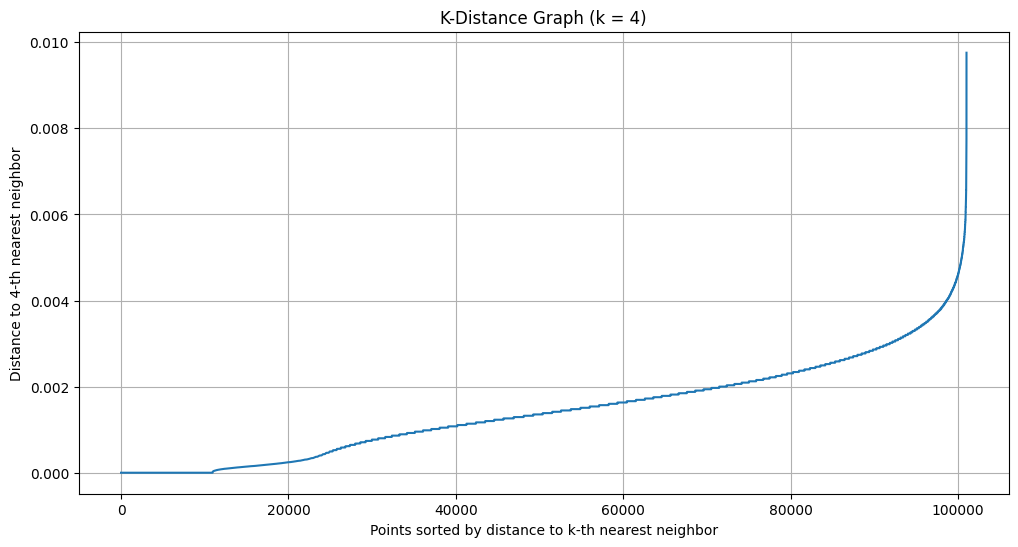

In [36]:
#DBSCAN has two crucial parameters that need to be set:
#eps (epsilon): This defines the maximum distance between two samples for one to be considered as in the neighborhood of the other. It's like the radius of the circle around each data point.

#min_samples: This is the number of samples  in a neighborhood for a point to be considered as a core point. A core point is a point that is dense enough to be the center of a cluster.

#for min_samples = 2 * #features =4

from sklearn.neighbors import NearestNeighbors #  for k-distance plot

# --- Determining optimal 'eps' using K-Distance Graph ---

# Set k (min_samples) based on  (2 * number of features)
min_samples_val = 4 # Using scaled_df as it's the DataFrame version of SCALED_FEATURES
print(f"Using min_samples = {min_samples_val} (2 * number of features)")

# Fit the NearestNeighbors model to the scaled data
# n_neighbors is k + 1 because the point itself is included in its own neighborhood
neighbors = NearestNeighbors(n_neighbors=min_samples_val + 1) #if we want the distance to the 4th nearest other neighbor, we ask for 5 neighbors. we are tying ot find the 4 closetst points to each point
neighbors_fit = neighbors.fit(scaled_df) #his line trains the NearestNeighbors model by building an efficient internal data structure, from 'scaled_df', enabling rapid lookups for closest points in later steps.

# Get the distances and indices of the nearest neighbors
distances, indices = neighbors_fit.kneighbors(scaled_df)

# Sort the distances (specifically the k-th distance for each point)
# The last column of 'distances' array contains the distance to the (k+1)-th nearest neighbor,
# which is effectively the k-th nearest unique neighbor if we exclude the point itself.
distances = np.sort(distances[:, min_samples_val], axis=0) #sort teh distances

# Plot the K-Distance Graph
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title(f'K-Distance Graph (k = {min_samples_val})')
plt.xlabel('Points sorted by distance to k-th nearest neighbor')
plt.ylabel(f'Distance to {min_samples_val}-th nearest neighbor')
plt.grid(True)
plt.show()



#After looking at teh graph: the elbow point is 0.004
#For DBSCAN, this 0.004 will be the eps (epsilon) parameter.

#It means that any two data points in the scaled_df are considered neighbors if the Euclidean distance between them is less than or equal to 0.004.

#eps = 0.004 (the value  identified from the K-Distance graph)
#min_samples = 4 --> 2 * number_of_features

In [37]:
from sklearn.cluster import DBSCAN 

# --- Run DBSCAN Clustering ---

# Initializing the DBSCAN model with the chosen parameters
dbscan = DBSCAN(eps=0.010, min_samples=4)

# Fit the model to theb scaled features and predict the clusters
# .fit_predict() performs both fitting (learning the clusters) and predicting labels in one step
cluster_labels = dbscan.fit_predict(scaled_features) 

# --- Analyze DBSCAN Results ---

# Add the cluster labels back to the scaled DataFrame for easier analysis
scaled_df['DBSCAN_Cluster'] = cluster_labels

print("--- DBSCAN Cluster Labels (First 10 Rows) ---")
print(scaled_df.head(10))

# Get the unique cluster labels and their counts
unique_labels = np.unique(cluster_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0) # Count clusters, 
n_noise_points = np.sum(cluster_labels == -1)

print(f"\n--- DBSCAN Summary ---")
print(f"Estimated number of clusters found: {n_clusters}")
print(f"Estimated number of noise points (label -1): {n_noise_points}")
print(f"Cluster labels found: {unique_labels}")

# the distribution of points per cluster:
print("\n--- Points per Cluster (including noise) ---")
print(scaled_df['DBSCAN_Cluster'].value_counts().sort_index())

--- DBSCAN Cluster Labels (First 10 Rows) ---
     Amount  Hour_Of_Day  DBSCAN_Cluster
0 -0.391514     0.649625               0
1  0.217858     1.370989               1
2 -1.116128     0.649625               0
3  1.315049     0.649625               0
4 -0.335246    -1.658741               2
5  1.869354     1.082443               3
6  1.521743    -1.225922               4
7 -1.067127    -0.648831               5
8  1.594202    -0.071739               6
9  1.426353     0.361079               7

--- DBSCAN Summary ---
Estimated number of clusters found: 24
Estimated number of noise points (label -1): 0
Cluster labels found: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

--- Points per Cluster (including noise) ---
DBSCAN_Cluster
0     3982
1     4230
2     4343
3     4175
4     4158
5     4176
6     4262
7     4373
8     4150
9     4229
10    4182
11    4297
12    4327
13    4114
14    4161
15    4256
16    4285
17    4244
18    4208
19    4064
20    4200
21   


Using min_samples = 14 (2 * number of new features)
Index(['Type_Debit', 'Payment Method_Cash', 'Payment Method_Credit Card',
       'Payment Method_Debit Card', 'Payment Method_Mobile Payment',
       'Account Type_Credit', 'Account Type_Savings'],
      dtype='object')


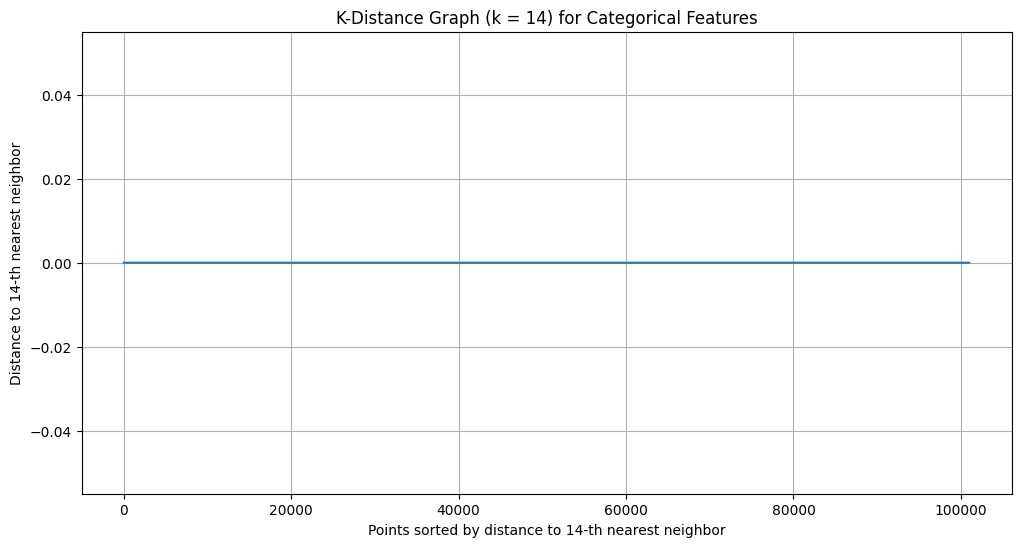

In [38]:
#---------------DBSCAN FOR CATAGEROICAL FEATURES-----------------------
# --- Determine optimal 'eps' using K-Distance Graph for One-Hot Encoded Features ---

# Update k (min_samples) based on the new number of features
categorical_features = ['Type', 'Payment Method', 'Account Type']

# Create a new DataFrame with the one-hot encoded features
encoded_df = pd.get_dummies(df[categorical_features], drop_first=True)
min_samples_val = 2 * len(encoded_df.columns) # 2* 7
print(f"\nUsing min_samples = {min_samples_val} (2 * number of new features)")
print(encoded_df.columns)
# Fit the NearestNeighbors model to your encoded data
neighbors = NearestNeighbors(n_neighbors=min_samples_val + 1)
neighbors_fit = neighbors.fit(encoded_df)

# Get the distances and indices
distances, indices = neighbors_fit.kneighbors(encoded_df)

# Sort the distances to the k-th nearest neighbor
distances = np.sort(distances[:, min_samples_val], axis=0)

# Plot the K-Distance Graph
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title(f'K-Distance Graph (k = {min_samples_val}) for Categorical Features')
plt.xlabel(f'Points sorted by distance to {min_samples_val}-th nearest neighbor')
plt.ylabel(f'Distance to {min_samples_val}-th nearest neighbor')
plt.grid(True)
plt.show()



In [39]:
# --- STEP 1: One-Hot Encode the Categorical Features ---
categorical_features = ['Type', 'Payment Method', 'Account Type']
encoded_df = pd.get_dummies(df[categorical_features], drop_first=True)
print("Number of new features for DBSCAN:", len(encoded_df.columns))

# --- STEP 2: Run DBSCAN on One-Hot Encoded Features ---
min_samples_val = 2 * len(encoded_df.columns)
print(f"Using min_samples = {min_samples_val} (2 * {len(encoded_df.columns)} new features)")

dbscan_categorical = DBSCAN(eps=0.5, min_samples=min_samples_val)
cluster_labels_cat = dbscan_categorical.fit_predict(encoded_df) #fit learns the the density structure fof the data and predit then assigns a cluster label to every single data point.
# fit_preditt() method returns an array of cluster labels ( names of all the clusters 1 2 3..)
# --- STEP 3: Adding the cluster labels to the original DataFrame ---
df['DBSCAN_Cluster_Cat'] = cluster_labels_cat #creating a column to store the cluster_labels_cat data

# --- STEP 4: Analyze the Categorical Clusters with a different syntax ---
def get_mode(series):
    return series.mode()[0] if not series.mode().empty else 'N/A'

# Create the aggregation dictionary for the categorical columns
agg_dict = {
    'Type': get_mode,
    'Payment Method': get_mode,
    'Account Type': get_mode
}

# Group the DataFrame by the new cluster labels
grouped_data = df.groupby('DBSCAN_Cluster_Cat') # grpoupts the dataframe based on the unique values in a specified column

# Perform the aggregation on the categorical columns
categorical_cluster_summary = grouped_data.agg(agg_dict) #The .agg() method then takes the grouped_data object and applies one or more aggregation functions to each of the 30 groups. beaiscally gets teh mode for each features

# Add the number of transactions per cluster as a new column
categorical_cluster_summary['Number_of_Transactions'] = grouped_data.size() #returns numbers of rows: 3197, 4097..

print("\n--- Summary of Categorical Clusters ---")
print(categorical_cluster_summary)



Number of new features for DBSCAN: 7
Using min_samples = 14 (2 * 7 new features)

--- Summary of Categorical Clusters ---
                      Type  Payment Method Account Type  \
DBSCAN_Cluster_Cat                                        
0                   Credit      Debit Card     Checking   
1                   Credit   Bank Transfer      Savings   
2                    Debit   Bank Transfer       Credit   
3                   Credit     Credit Card     Checking   
4                   Credit     Credit Card       Credit   
5                    Debit  Mobile Payment     Checking   
6                    Debit  Mobile Payment      Savings   
7                   Credit   Bank Transfer     Checking   
8                    Debit            Cash      Savings   
9                    Debit            Cash       Credit   
10                   Debit      Debit Card       Credit   
11                   Debit   Bank Transfer      Savings   
12                   Debit      Debit Card     Check

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer # to convert  text descriptions into numerical vectors.
from sklearn.cluster import DBSCAN
import numpy as np #for numerical  operation

# --- STEP 1: Vectorize the TransactionDescription text using TF-IDF ---
#from asher kelly's code
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

# Fit and transform the text column
tfidf_vectors = vectorizer.fit_transform(df["Description"])

print("TF-IDF Vectorization Complete.")
print("Shape of TF-IDF vectors (n_transactions, n_features):", tfidf_vectors.shape)

# --- STEP 2: Run DBSCAN on the TF-IDF Vectors ---
# use a small eps vaue at first
dbscan_tfidf = DBSCAN(eps=0.7, min_samples=5)

# Fit the model to the  TF-IDF vectors

cluster_labels_tfidf = dbscan_tfidf.fit_predict(tfidf_vectors)

# --- STEP 3: Analyze the results ---
df['DBSCAN_Cluster_TFIDF'] = cluster_labels_tfidf

print("\n--- DBSCAN Summary for TF-IDF Features ---")
unique_labels_tfidf = np.unique(cluster_labels_tfidf)
n_clusters_tfidf = len(unique_labels_tfidf) - (1 if -1 in unique_labels_tfidf else 0)
n_noise_points_tfidf = np.sum(cluster_labels_tfidf == -1)

print(f"Estimated number of clusters found: {n_clusters_tfidf}")
print(f"Estimated number of noise points (label -1): {n_noise_points_tfidf}")
print(f"Cluster labels found: {unique_labels_tfidf}")

print("\n--- Points per Cluster (including noise) for TF-IDF Features ---")
print(df['DBSCAN_Cluster_TFIDF'].value_counts().sort_index())

TF-IDF Vectorization Complete.
Shape of TF-IDF vectors (n_transactions, n_features): (101000, 46)


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer



# Get the feature names from the TF-IDF vectorizer
feature_names = vectorizer.get_feature_names_out() #all the names adn phrases

# Create a combined DataFrame for easier manipulation
df_combined = pd.DataFrame(tfidf_vectors.todense(), columns=feature_names) #akes the  tfidf_vectors (which are in a sparse matrix format) and converts them into a pandas DataFrame
df_combined['DBSCAN_Cluster_TFIDF'] = df['DBSCAN_Cluster_TFIDF'].values

# Define a function to get the top words for a given cluster
def get_top_words(cluster_df, top_n=10):
    # Calculate the mean TF-IDF vector for the cluster
    cluster_mean_vector = cluster_df.drop('DBSCAN_Cluster_TFIDF', axis=1).mean(axis=0)

    # Get the indices of the top N words
    top_word_indices = np.argsort(cluster_mean_vector)[::-1][:top_n]

    # Get the actual words and their scores
    top_words = feature_names[top_word_indices]
    return list(top_words)

# Group the combined DataFrame by the cluster labels and apply the function
cluster_summary_list = []
for cluster_id, group in df_combined.groupby('DBSCAN_Cluster_TFIDF'):
    if cluster_id != -1:
        top_words = get_top_words(group, top_n=3)
        num_transactions = len(group)
        cluster_summary_list.append({'DBSCAN_Cluster_TFIDF': cluster_id,
                                     'Top_Words': top_words,
                                     'Number_of_Transactions': num_transactions})

# Create the final summary DataFrame
categorical_cluster_summary = pd.DataFrame(cluster_summary_list)
categorical_cluster_summary.set_index('DBSCAN_Cluster_TFIDF', inplace=True)

#  the pandas option to show the full column content
pd.set_option('display.max_colwidth', None)

print("\n--- Summary of TF-IDF Clusters (Corrected) ---")
print(categorical_cluster_summary)


--- Summary of TF-IDF Clusters (Corrected) ---
                                                          Top_Words  \
DBSCAN_Cluster_TFIDF                                                  
0                             [target, groceries target, groceries]   
1                           [walmart, groceries walmart, groceries]   
2                                   [meal, mcdonald meal, mcdonald]   
3                     [spotify, spotify subscription, subscription]   
4                     [netflix, netflix subscription, subscription]   
5                               [amazon, amazon purchase, purchase]   
6                                           [uber ride, uber, ride]   
7                                           [lyft, lyft ride, ride]   
8                               [tuition, tuition payment, payment]   
9                                   [online course, online, course]   
10                                [gym membership, gym, membership]   
11                           

In [ ]:
#Cluster 0 (12,015 transactions): Top words are target, groceries target, and groceries.

#Interpretation: This cluster is clearly about grocery purchases at Target.

#Cluster 1 (12,342 transactions): Top words are walmart, groceries walmart, and groceries.

#Interpretation: This cluster is about grocery purchases at Walmart.

#Cluster 2 (11,984 transactions): Top words are meal, mcdonald meal, and mcdonald.

#Interpretation: This cluster is about meals at McDonald's.

#Cluster 5 (12,356 transactions): Top words are amazon, amazon purchase, and purchase.

#Interpretation: This cluster is about general purchases from Amazon.



In [ ]:
################### DBSCAN with Categorical converted features/ Embeddings (BERT) ########################
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer # for generating BERT embeddings
from sklearn.cluster import DBSCAN #or the clustering algorithm

# --- STEP 1: Combine the specified features into a single text string ---
###### This creates a new column in the DataFrame named Combined_Text_Final. It combines the text from four different columns (Description, Category, Notes, Merchant) into a single string for each transaction. The .fillna('') part ensures that if any of these columns are empty, the code doesn't break and just adds a blank space. to crate a single feature for BERT to analyze.

print("Combining Description, Category, notes, and merchant into a single text description...")
# Create a new column with the combined text.
#  handle any missing values by replacing them with an empty string.
df['Combined_Text_Final'] = df['Description'].fillna('') + ' ' + \
                          df['Category'].fillna('') + ' ' + \
                          df['Notes'].fillna('') + ' ' + \
                          df['Merchant'].fillna('')

# --- STEP 2: Create Embeddings using a pre-trained BERT Model ---
print("Loading BERT model...")
model = SentenceTransformer('all-MiniLM-L6-v2') #this model is designed to generate sentecen emebeddings quickly

print("Generating embeddings for the final combined text...")
# Use the new, rich combined text column to get the embeddings
bert_embeddings_final = model.encode(df['Combined_Text_Final'].tolist()) #tthis takes the new Combined_Text_Final column and uses the BERT model to convert each text string into a numerical vector (an embedding). 

print("BERT Embeddings Complete.")
print("Shape of BERT embeddings (n_transactions, n_features):", bert_embeddings_final.shape) #I have 101,000 transactions, and each one is represented by a vector with 384 numbers

# --- STEP 3: Run DBSCAN on the BERT Embeddings ---
# using the same starting parameters from TF-IDF.
dbscan_bert = DBSCAN(eps=0.7, min_samples=5)

# Fit the model to  new BERT embeddings
cluster_labels_bert_final = dbscan_bert.fit_predict(bert_embeddings_final) #This runs the DBSCAN algorithms

# --- STEP 4: Analyze the results ---
df['DBSCAN_Cluster_BERT_Final'] = cluster_labels_bert_final #This adds the cluster labels generated by DBSCAN as a new column to the  original DataFrame

print("\n--- DBSCAN Summary for Final Combined BERT Embeddings ---")
unique_labels_bert_final = np.unique(cluster_labels_bert_final)
n_clusters_bert_final = len(unique_labels_bert_final) - (1 if -1 in unique_labels_bert_final else 0)
n_noise_points_bert_final = np.sum(cluster_labels_bert_final == -1)

print(f"Estimated number of clusters found: {n_clusters_bert_final}")
print(f"Estimated number of noise points (label -1): {n_noise_points_bert_final}")
print(f"Cluster labels found: {unique_labels_bert_final}")

print("\n--- Points per Cluster (including noise) for Final Combined BERT Embeddings ---")
print(df['DBSCAN_Cluster_BERT_Final'].value_counts().sort_index())

Combining Description, Category, notes, and merchant into a single text description...
Loading BERT model...


c:\Users\souma\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\souma\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not insta

Generating embeddings for the final combined text...
BERT Embeddings Complete.
Shape of BERT embeddings (n_transactions, n_features): (101000, 384)

--- DBSCAN Summary for Final Combined BERT Embeddings ---
Estimated number of clusters found: 100
Estimated number of noise points (label -1): 0
Cluster labels found: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]

--- Points per Cluster (including noise) for Final Combined BERT Embeddings ---
DBSCAN_Cluster_BERT_Final
0     24358
1     12297
2     12157
3     12075
4     12074
      ...  
95       27
96       42
97       16
98       22
99       23
Name: count, Length: 100, dtype: int64


In [ ]:
# --- Analyze the BERT Clusters by looking at samples ---
# Display settings must be set before printing
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)


def summarize_bert_clusters(df, cluster_col, sample_size=3):
    cluster_summary = df.groupby(cluster_col).apply( #groups the clusters
        lambda x: pd.Series({
            'Number_of_Transactions': len(x),
            'Sample_Descriptions': x['Combined_Text_Final'].sample(min(len(x), sample_size), random_state=1).tolist()
        })
    )
    return cluster_summary.sort_index()

bert_cluster_summary = summarize_bert_clusters(df, 'DBSCAN_Cluster_BERT_Final')

print("\n--- Summary of BERT Clusters ---")
print(bert_cluster_summary)

print("\nInterpretation Notes:")
print("- The 'Number_of_Transactions' column shows the size of each cluster.")
print("- The 'Sample_Descriptions' column gives examples of the combined text in that cluster.")
print("- By reading the samples, you can understand the theme of each cluster.")


--- Summary of BERT Clusters ---
                           Number_of_Transactions  \
DBSCAN_Cluster_BERT_Final                           
0                                           24358   
1                                           12297   
2                                           12157   
3                                           12075   
4                                           12074   
5                                           11901   
6                                           11989   
7                                              25   
8                                             321   
9                                              21   
10                                            172   
11                                             36   
12                                             36   
13                                             59   
14                                             83   
15                                            116   
16          

C:\Users\souma\AppData\Local\Temp\ipykernel_7252\3504341878.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_summary = df.groupby(cluster_col).apply(


In [ ]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
import numpy as np

# --- STEP 1: Run Agglomerative Clustering on the BERT Embeddings ---
print("Running Agglomerative Clustering on BERT Embeddings...")
#Quick NOtes
#  I need to decide how many clusters to have (n_clusters)
# A good starting point is to use the number of clusters DBSCAN found (100)
# 'metric' is how we measure distance between points, 'euclidean' is standard.
# 'linkage' is how we measure distance between clusters. 'ward' is a common choice.
agg_clustering = AgglomerativeClustering(n_clusters=100, metric='euclidean', linkage='ward')

# Fit the model and get the cluster labels
cluster_labels_agg = agg_clustering.fit_predict(bert_embeddings_final)

# --- STEP 2: Analyze the results ---
df['Agglomerative_Cluster_BERT'] = cluster_labels_agg

print("\n--- Agglomerative Clustering Summary for BERT Embeddings ---")
unique_labels_agg = np.unique(cluster_labels_agg)
n_clusters_agg = len(unique_labels_agg)

print(f"Number of clusters found: {n_clusters_agg}")
print(f"Cluster labels found: {unique_labels_agg}")

print("\n--- Points per Cluster ---")
print(df['Agglomerative_Cluster_BERT'].value_counts().sort_index())

Running Agglomerative Clustering on BERT Embeddings...

--- Agglomerative Clustering Summary for BERT Embeddings ---
Number of clusters found: 100
Cluster labels found: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]

--- Points per Cluster ---
Agglomerative_Cluster_BERT
0        81
1        53
2        57
3       146
4       122
5        42
6        91
7        85
8        80
9        46
10       88
11       61
12       68
13       53
14       77
15       76
16       86
17       53
18       56
19       55
20       63
21       72
22      105
23       55
24       49
25    12051
26       59
27       48
28       65
29       55
30       53
31       57
32       47
33       52
34      139
35       50
36       60
37       82
38       54
39

In [ ]:
# --- Analyze the Agglomerative Clusters by looking at samples ---
def summarize_bert_clusters(df, cluster_col, sample_size=3):
    cluster_summary = df.groupby(cluster_col).apply(
        lambda x: pd.Series({
            'Number_of_Transactions': len(x),
            'Sample_Descriptions': x['Combined_Text_Final'].sample(min(len(x), sample_size), random_state=1).tolist()
        })
    )
    return cluster_summary.sort_index()

agg_cluster_summary = summarize_bert_clusters(df, 'Agglomerative_Cluster_BERT')

# Display the summary for all clusters
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

print("\n--- Summary of Agglomerative Clusters ---")
print(agg_cluster_summary)

print("\nInterpretation Notes:")
print("- The 'Number_of_Transactions' column shows the size of each cluster.")
print("- The 'Sample_Descriptions' column gives examples of the combined text in that cluster.")
print("- By reading the samples, you can understand the theme of each cluster.")


--- Summary of Agglomerative Clusters ---
                            Number_of_Transactions  \
Agglomerative_Cluster_BERT                           
0                                               81   
1                                               53   
2                                               57   
3                                              146   
4                                              122   
5                                               42   
6                                               91   
7                                               85   
8                                               80   
9                                               46   
10                                              88   
11                                              61   
12                                              68   
13                                              53   
14                                              77   
15                                     

C:\Users\souma\AppData\Local\Temp\ipykernel_7252\2119464124.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_summary = df.groupby(cluster_col).apply(
